# Lab 13: CityLearn Demand Forecasting Project

**Student Name:** Yousaf Tahir  
**Registration Number:** 22JZELE0479  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Peshawar - Nowshera Campus  

## Project Overview

This notebook presents a forecasting framework based on machine learning and deep learning techniques using the CityLearn dataset. The workflow includes loading and integrating building energy consumption data with weather conditions, electricity pricing, and carbon intensity information. The data is then processed, transformed into time-series sequences, and used to train an LSTM model for predicting district-level electricity demand.

## Goal of this Lab
Explore the CityLearn dataset and review the available schema and data files.
Gather electricity consumption data from multiple buildings and aggregate it to obtain district-level demand.
Integrate demand data with weather variables, electricity price information, and carbon intensity records.
Handle missing values and generate relevant features for forecasting applications.
Apply data normalization and prepare input-output sequences using a predefined lookback period.
Develop, train, and assess an LSTM-based forecasting model for predicting future district electricity demand.


## Section 1: Working Directory and Library Imports
This section sets the CityLearn Assignment working directory and imports data handling, visualization, preprocessing, TensorFlow/Keras, and evaluation libraries.


## Environment Repair Cell
Run the next cell only if imports fail with `ValueError: numpy.dtype size changed`. After it finishes, restart the kernel and run the notebook from the top.


In [2]:
# ENVIRONMENT REPAIR CELL
# Run this only when you see: ValueError: numpy.dtype size changed
# After installation finishes, restart the kernel before running imports again.
import sys


!{sys.executable} -m pip install --upgrade --force-reinstall "numpy==1.26.4" "pandas==2.2.2" "scipy==1.13.1" "scikit-learn==1.5.1" "h5py==3.11.0"

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
  Using cached pandas-2.2.2-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached scipy-1.13.1-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.5.1-cp310-cp310-win_amd64.whl.metadata (12 kB)
  Using cached h5py-3.11.0-cp310-cp310-win_amd64.whl.metadata (2.5 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
Using cached pandas-2.2.2-cp310-cp310-win_amd64.whl (11.6 MB)
Using cached scipy-1.13.1-cp310-cp310-win_amd64.whl (46.2 MB)
Using cached scikit_learn-1.5.1-cp310-cp3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
citylearn 2.1.2 requires pandas==1.3.5, but you have pandas 2.2.2 which is incompatible.
citylearn 2.1.2 requires scikit-learn==1.0.2, but you have scikit-learn 1.5.1 which is incompatible.


   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   --------------------- ------------------  6/11 [scipy]
   -----------

In [3]:
from pathlib import Path

# Keep every generated file beside this notebook instead of using a machine-specific Z: drive path.
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

print('Working directory:', NOTEBOOK_DIR)


Working directory: c:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 13


In [4]:
import json
import os
import pickle
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import explained_variance_score, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from citylearn.data import DataSet


In [5]:
# Re-import these here so this setup cell also works if it is run by itself.
import random
import numpy as np
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

model = None
start_epoch = 0
time_steps = 48
target_column = 'district_net_electricity_consumption'


In [6]:
citylearn_dataset = DataSet()


def _normalize_dataset_names(value):
    if value is None:
        return []
    if isinstance(value, dict):
        return list(value.keys())
    if isinstance(value, (list, tuple, set)):
        return list(value)
    return []


def get_citylearn_dataset_names(dataset):
    """Return dataset names across different CityLearn versions."""
    method_names = ['get_dataset_names', 'get_names', 'list_datasets', 'dataset_names']

    for owner in (dataset, DataSet):
        for method_name in method_names:
            member = getattr(owner, method_name, None)
            if member is None:
                continue
            try:
                value = member() if callable(member) else member
                names = _normalize_dataset_names(value)
                if names:
                    return names
            except TypeError:
                continue

    for attr_name in ['datasets', 'dataset_map', 'schema']:
        value = getattr(dataset, attr_name, None)
        names = _normalize_dataset_names(value)
        if names:
            return names

    return []


def get_citylearn_schema(dataset, dataset_name):
    """Return the dataset schema across different CityLearn versions."""
    for owner in (dataset, DataSet):
        for method_name in ['get_schema', 'get_dataset_schema', 'load_schema']:
            member = getattr(owner, method_name, None)
            if member is None:
                continue
            try:
                return member(dataset_name)
            except TypeError:
                try:
                    return member(name=dataset_name)
                except TypeError:
                    continue

    raise AttributeError(
        'Could not find a CityLearn schema-loading method. '
        f'Available DataSet attributes include: {dir(dataset)}'
    )


dataset_names = get_citylearn_dataset_names(citylearn_dataset)
print('Available CityLearn datasets:', sorted(dataset_names) if dataset_names else 'Could not list datasets; will try loading by name directly.')


Available CityLearn datasets: ['baeda_3dem', 'citylearn_challenge_2020_climate_zone_1', 'citylearn_challenge_2020_climate_zone_2', 'citylearn_challenge_2020_climate_zone_3', 'citylearn_challenge_2020_climate_zone_4', 'citylearn_challenge_2021', 'citylearn_challenge_2022_phase_1', 'citylearn_challenge_2022_phase_2', 'citylearn_challenge_2022_phase_3', 'citylearn_challenge_2022_phase_all', 'citylearn_challenge_2023_phase_1', 'citylearn_challenge_2023_phase_2_local_evaluation', 'citylearn_challenge_2023_phase_2_online_evaluation_1', 'citylearn_challenge_2023_phase_2_online_evaluation_2', 'citylearn_challenge_2023_phase_2_online_evaluation_3', 'citylearn_challenge_2023_phase_3_1', 'citylearn_challenge_2023_phase_3_2', 'citylearn_challenge_2023_phase_3_3']


## Section 2: CityLearn Dataset Loading and Schema Inspection
The following cells inspect available CityLearn datasets, select the required challenge dataset, and read schema/building information.


In [7]:
dataset_name = 'citylearn_challenge_2022_phase_all'

if dataset_names and dataset_name not in dataset_names:
    raise ValueError(
        f"Dataset {dataset_name!r} was not found. Available datasets: {sorted(dataset_names)}"
    )

schema = get_citylearn_schema(citylearn_dataset, dataset_name)
root_directory = schema['root_directory']

print(root_directory)
print(schema.keys())


c:\Users\hp\anaconda3\envs\dsp\lib\site-packages\citylearn\data\citylearn_challenge_2022_phase_all
dict_keys(['root_directory', 'central_agent', 'simulation_start_time_step', 'simulation_end_time_step', 'episode_time_steps', 'rolling_episode_split', 'random_episode_split', 'seconds_per_time_step', 'observations', 'actions', 'agent', 'reward_function', 'buildings'])


In [8]:
building_names = list(schema['buildings'].keys())
building_names[:5], len(building_names)

(['Building_1', 'Building_2', 'Building_3', 'Building_4', 'Building_5'], 17)

In [9]:
building_data = []

for building_name in building_names:
    filename = schema['buildings'][building_name]['energy_simulation']
    filepath = os.path.join(root_directory, filename)
    
    data = pd.read_csv(filepath)
    data['building_name'] = building_name
    building_data.append(data)

building_df = pd.concat(building_data, axis=0, ignore_index=True)
building_df.head()

,Month,Hour,Day Type,Daylight Savings Status,Indoor Temperature [C],Average Unmet Cooling Setpoint Difference [C],Indoor Relative Humidity [%],Equipment Electric Power [kWh],DHW Heating [kWh],Cooling Load [kWh],Heating Load [kWh],Solar Generation [W/kW],building_name
0,7.0,24.0,7.0,0,NaN,NaN,NaN,2.275800,0,0,0,0.0,Building_1
1,8.0,1.0,1.0,0,NaN,NaN,NaN,0.851167,0,0,0,0.0,Building_1
2,8.0,2.0,1.0,0,NaN,NaN,NaN,0.834600,0,0,0,0.0,Building_1
3,8.0,3.0,1.0,0,NaN,NaN,NaN,0.838167,0,0,0,0.0,Building_1
4,8.0,4.0,1.0,0,NaN,NaN,NaN,1.478433,0,0,0,0.0,Building_1


In [10]:
building_df.shape

(148920, 13)

In [11]:
building_df.columns

Index(['Month', 'Hour', 'Day Type', 'Daylight Savings Status',
       'Indoor Temperature [C]',
       'Average Unmet Cooling Setpoint Difference [C]',
       'Indoor Relative Humidity [%]', 'Equipment Electric Power [kWh]',
       'DHW Heating [kWh]', 'Cooling Load [kWh]', 'Heating Load [kWh]',
       'Solar Generation [W/kW]', 'building_name'],
      dtype='object')

## Section 3: Building, Weather, Pricing, and Carbon Data Collection
This section loads building energy simulation files and supporting weather, pricing, and carbon intensity files required for district-level forecasting.


In [12]:
weather_file = schema['buildings'][building_names[0]]['weather']
pricing_file = schema['buildings'][building_names[0]]['pricing']
carbon_file = schema['buildings'][building_names[0]]['carbon_intensity']

weather = pd.read_csv(os.path.join(root_directory, weather_file))
pricing = pd.read_csv(os.path.join(root_directory, pricing_file))
carbon_intensity = pd.read_csv(os.path.join(root_directory, carbon_file))

weather.head(), pricing.head(), carbon_intensity.head()

(   Outdoor Drybulb Temperature [C]  Relative Humidity [%]  \
 0                             20.0                   84.0   
 1                             20.1                   79.0   
 2                             19.7                   78.0   
 3                             19.3                   78.0   
 4                             18.9                   78.0   
 
    Diffuse Solar Radiation [W/m2]  Direct Solar Radiation [W/m2]  \
 0                             0.0                            0.0   
 1                             0.0                            0.0   
 2                             0.0                            0.0   
 3                             0.0                            0.0   
 4                             0.0                            0.0   
 
    6h Prediction Outdoor Drybulb Temperature [C]  \
 0                                           18.3   
 1                                           19.4   
 2                                           21.1  

In [13]:
building_df.isnull().sum()

Month                                                 0
Hour                                                  0
Day Type                                              0
Daylight Savings Status                               0
Indoor Temperature [C]                           148920
Average Unmet Cooling Setpoint Difference [C]    148920
Indoor Relative Humidity [%]                     148920
Equipment Electric Power [kWh]                        0
DHW Heating [kWh]                                     0
Cooling Load [kWh]                                    0
Heating Load [kWh]                                    0
Solar Generation [W/kW]                               0
building_name                                         0
dtype: int64

In [14]:
building_df = building_df.dropna(axis=1, how='all')
weather = weather.dropna(axis=1, how='all')
pricing = pricing.dropna(axis=1, how='all')
carbon_intensity = carbon_intensity.dropna(axis=1, how='all')

building_df.shape, weather.shape, pricing.shape, carbon_intensity.shape

((148920, 10), (8760, 16), (8760, 4), (8760, 1))

In [15]:
building_df.describe()

,Month,Hour,Day Type,Daylight Savings Status,Equipment Electric Power [kWh],DHW Heating [kWh],Cooling Load [kWh],Heating Load [kWh],Solar Generation [W/kW]
count,148920.000000,148920.00000,148920.000000,148920.0,148920.000000,148920.0,148920.0,148920.0,148920.000000
mean,6.526027,12.50000,3.992466,0.0,1.139162,0.0,0.0,0.0,155.877055
std,3.447863,6.92221,2.003414,0.0,1.108441,0.0,0.0,0.0,240.830052
min,1.000000,1.00000,1.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
25%,4.000000,6.75000,2.000000,0.0,0.359112,0.0,0.0,0.0,0.000000
50%,7.000000,12.50000,4.000000,0.0,0.789617,0.0,0.0,0.0,0.000000
75%,10.000000,18.25000,6.000000,0.0,1.575487,0.0,0.0,0.0,265.795833
max,12.000000,24.00000,7.000000,0.0,8.846017,0.0,0.0,0.0,976.250000


In [16]:
possible_demand_columns = [
    'net_electricity_consumption',
    'Equipment Electric Power [kWh]',
    'equipment_electric_power',
    'non_shiftable_load',
    'Non Shiftable Load [kWh]'
]

demand_column = None

for col in possible_demand_columns:
    if col in building_df.columns:
        demand_column = col
        break

print('Selected demand column:', demand_column)

Selected demand column: Equipment Electric Power [kWh]


## Section 4: Data Cleaning and Exploratory Analysis
The following cells remove empty columns, check missing values, identify the demand column, summarize the dataset, and visualize average demand.


In [17]:
if demand_column is None:
    numeric_columns = building_df.select_dtypes(include=[np.number]).columns.tolist()
    if not numeric_columns:
        raise ValueError('No numeric demand column candidates were found in building_df.')
    demand_column = numeric_columns[-1]
    print('Fallback demand column:', demand_column)


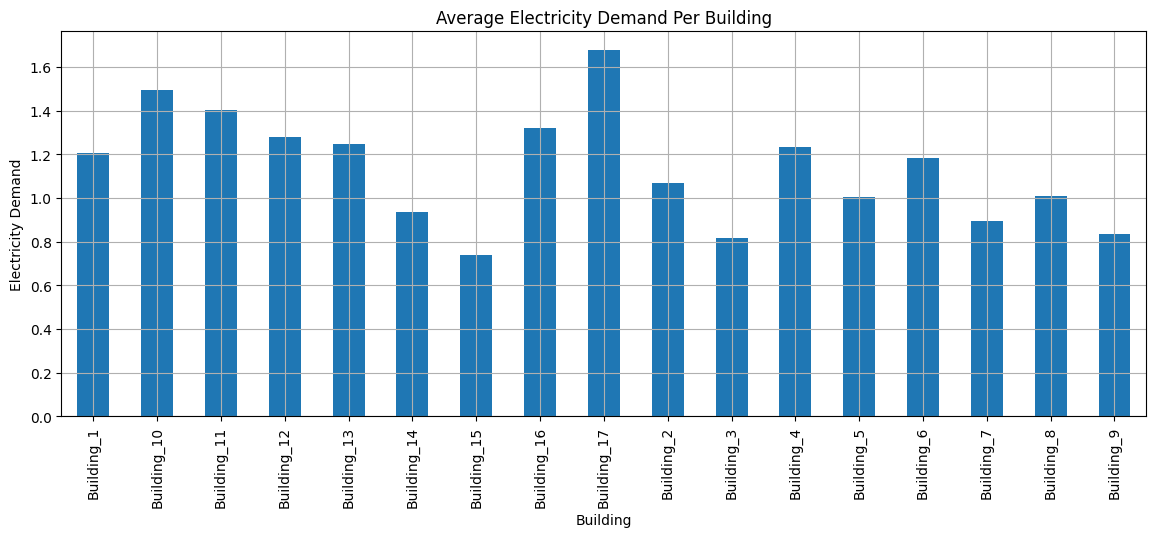

In [18]:
building_df.groupby('building_name')[demand_column].mean().plot(kind='bar', figsize=(14,5))
plt.title('Average Electricity Demand Per Building')
plt.xlabel('Building')
plt.ylabel('Electricity Demand')
plt.grid()
plt.show()

In [19]:
building_df['time_step'] = building_df.groupby('building_name').cumcount()

district_load = building_df.groupby('time_step')[demand_column].sum().reset_index()
district_load = district_load.rename(columns={demand_column: target_column})

district_load.head()

,time_step,district_net_electricity_consumption
0,0,17.191467
1,1,12.272112
2,2,11.015850
3,3,10.258206
4,4,11.480795


In [20]:
weather['time_step'] = np.arange(len(weather))
pricing['time_step'] = np.arange(len(pricing))
carbon_intensity['time_step'] = np.arange(len(carbon_intensity))

data = district_load.merge(weather, on='time_step', how='left')
data = data.merge(pricing, on='time_step', how='left')
data = data.merge(carbon_intensity, on='time_step', how='left')

data.head()

,time_step,district_net_electricity_consumption,Outdoor Drybulb Temperature [C],Relative Humidity [%],Diffuse Solar Radiation [W/m2],Direct Solar Radiation [W/m2],6h Prediction Outdoor Drybulb Temperature [C],12h Prediction Outdoor Drybulb Temperature [C],24h Prediction Outdoor Drybulb Temperature [C],6h Prediction Relative Humidity [%],...,12h Prediction Diffuse Solar Radiation [W/m2],24h Prediction Diffuse Solar Radiation [W/m2],6h Prediction Direct Solar Radiation [W/m2],12h Prediction Direct Solar Radiation [W/m2],24h Prediction Direct Solar Radiation [W/m2],Electricity Pricing [$/kWh],6h Prediction Electricity Pricing [$/kWh],12h Prediction Electricity Pricing [$/kWh],24h Prediction Electricity Pricing [$/kWh],kg_CO2/kWh
0,0,17.191467,20.0,84.0,0.0,0.0,18.3,22.8,20.0,81.0,...,964.0,0.0,100.0,815.0,0.0,0.22,0.22,0.22,0.22,0.170724
1,1,12.272112,20.1,79.0,0.0,0.0,19.4,22.8,19.4,79.0,...,966.0,0.0,444.0,747.0,0.0,0.22,0.22,0.22,0.22,0.157319
2,2,11.015850,19.7,78.0,0.0,0.0,21.1,22.2,19.4,73.0,...,683.0,0.0,592.0,291.0,0.0,0.22,0.22,0.22,0.22,0.154503
3,3,10.258206,19.3,78.0,0.0,0.0,22.2,22.8,19.4,71.0,...,522.0,0.0,491.0,153.0,0.0,0.22,0.22,0.22,0.22,0.150945
4,4,11.480795,18.9,78.0,0.0,0.0,21.7,22.2,18.9,73.0,...,444.0,0.0,734.0,174.0,0.0,0.22,0.22,0.54,0.22,0.151820


In [21]:
data = data.ffill()
data = data.bfill()

data.isnull().sum().sum()

0

## Section 5: Feature Engineering and Dataset Merging
This section creates district-level load, merges external features, fills missing values, and creates time-based/cyclic features for forecasting.


In [22]:
data['hour'] = data['time_step'] % 24
data['day'] = data['time_step'] // 24
data['day_of_week'] = data['day'] % 7
data['month'] = (data['day'] // 30) + 1

data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
data['day_sin'] = np.sin(2 * np.pi * data['day_of_week'] / 7)
data['day_cos'] = np.cos(2 * np.pi * data['day_of_week'] / 7)

# Extra time-series features for better validation performance
# Lag features help the model learn previous demand behaviour.
data['load_lag_1'] = data[target_column].shift(1)
data['load_lag_2'] = data[target_column].shift(2)
data['load_lag_24'] = data[target_column].shift(24)
data['load_lag_48'] = data[target_column].shift(48)

# Rolling features smooth sudden changes and help validation generalization.
data['load_roll_mean_3'] = data[target_column].rolling(window=3).mean()
data['load_roll_mean_6'] = data[target_column].rolling(window=6).mean()
data['load_roll_mean_24'] = data[target_column].rolling(window=24).mean()
data['load_roll_std_6'] = data[target_column].rolling(window=6).std()

# Remove NaN values created by lag and rolling features
data = data.dropna().reset_index(drop=True)

print('Shape after feature engineering:', data.shape)
data.head()


Shape after feature engineering: (8712, 39)


,time_step,district_net_electricity_consumption,Outdoor Drybulb Temperature [C],Relative Humidity [%],Diffuse Solar Radiation [W/m2],Direct Solar Radiation [W/m2],6h Prediction Outdoor Drybulb Temperature [C],12h Prediction Outdoor Drybulb Temperature [C],24h Prediction Outdoor Drybulb Temperature [C],6h Prediction Relative Humidity [%],...,day_sin,day_cos,load_lag_1,load_lag_2,load_lag_24,load_lag_48,load_roll_mean_3,load_roll_mean_6,load_roll_mean_24,load_roll_std_6
0,48,17.141848,19.4,79.0,0.0,0.0,19.4,25.0,18.9,84.0,...,0.974928,-0.222521,21.814878,19.309323,18.298268,17.191467,19.422016,22.830243,22.766031,4.577046
1,49,10.906312,20.0,78.0,0.0,0.0,21.1,25.0,19.4,76.0,...,0.974928,-0.222521,17.141848,21.814878,14.130234,12.272112,16.621013,19.768102,22.631701,5.460369
2,50,9.920445,19.4,84.0,0.0,0.0,22.8,24.4,20.0,66.0,...,0.974928,-0.222521,10.906312,17.141848,9.687203,11.015850,12.656201,16.924618,22.641419,5.394648
3,51,10.086987,19.4,84.0,0.0,0.0,24.4,25.0,19.4,64.0,...,0.974928,-0.222521,9.920445,10.906312,9.664550,10.258206,10.304581,14.863299,22.659021,5.218929
4,52,9.096178,19.4,84.0,0.0,0.0,23.9,23.9,18.9,66.0,...,0.974928,-0.222521,10.086987,9.920445,10.406228,11.480795,9.701203,13.161108,22.604436,5.143810


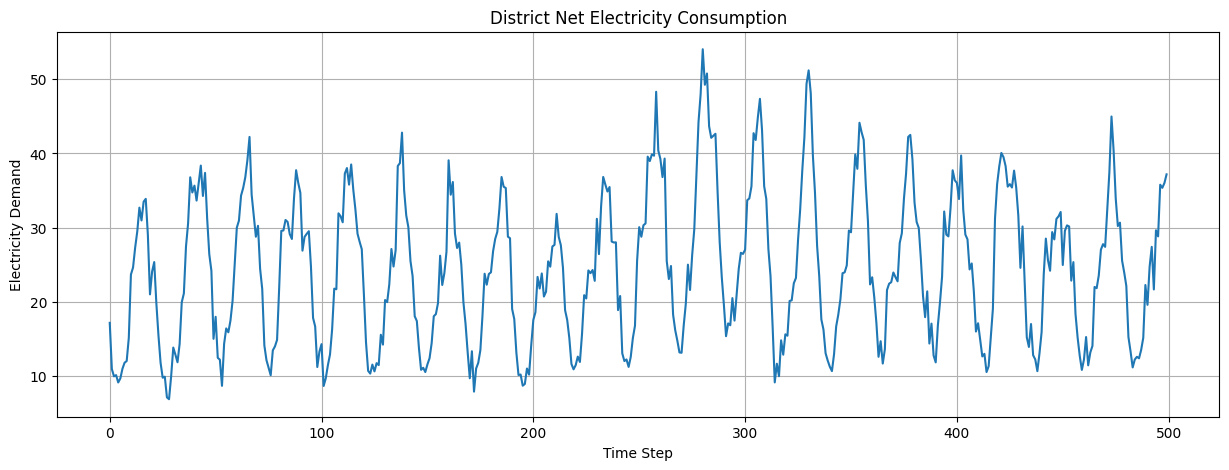

In [23]:
plt.figure(figsize=(15,5))
plt.plot(data[target_column][:500])
plt.title('District Net Electricity Consumption')
plt.xlabel('Time Step')
plt.ylabel('Electricity Demand')
plt.grid()
plt.show()

In [24]:
numeric_data = data.select_dtypes(include=[np.number])

correlation = numeric_data.corr()[target_column].sort_values(ascending=False)
correlation.head(15)

district_net_electricity_consumption             1.000000
load_roll_mean_3                                 0.937347
load_lag_1                                       0.895116
load_lag_24                                      0.813606
load_roll_mean_6                                 0.797303
load_lag_2                                       0.778913
load_lag_48                                      0.727340
load_roll_mean_24                                0.526143
load_roll_std_6                                  0.478531
kg_CO2/kWh                                       0.471496
Diffuse Solar Radiation [W/m2]                   0.453016
24h Prediction Diffuse Solar Radiation [W/m2]    0.450329
Direct Solar Radiation [W/m2]                    0.372037
24h Prediction Direct Solar Radiation [W/m2]     0.369098
hour                                             0.362909
Name: district_net_electricity_consumption, dtype: float64

In [25]:
feature_columns = list(numeric_data.columns)
feature_columns.remove(target_column)

selected_data = numeric_data[feature_columns + [target_column]].copy()

selected_data.head()


,time_step,Outdoor Drybulb Temperature [C],Relative Humidity [%],Diffuse Solar Radiation [W/m2],Direct Solar Radiation [W/m2],6h Prediction Outdoor Drybulb Temperature [C],12h Prediction Outdoor Drybulb Temperature [C],24h Prediction Outdoor Drybulb Temperature [C],6h Prediction Relative Humidity [%],12h Prediction Relative Humidity [%],...,day_cos,load_lag_1,load_lag_2,load_lag_24,load_lag_48,load_roll_mean_3,load_roll_mean_6,load_roll_mean_24,load_roll_std_6,district_net_electricity_consumption
0,48,19.4,79.0,0.0,0.0,19.4,25.0,18.9,84.0,58.0,...,-0.222521,21.814878,19.309323,18.298268,17.191467,19.422016,22.830243,22.766031,4.577046,17.141848
1,49,20.0,78.0,0.0,0.0,21.1,25.0,19.4,76.0,58.0,...,-0.222521,17.141848,21.814878,14.130234,12.272112,16.621013,19.768102,22.631701,5.460369,10.906312
2,50,19.4,84.0,0.0,0.0,22.8,24.4,20.0,66.0,58.0,...,-0.222521,10.906312,17.141848,9.687203,11.015850,12.656201,16.924618,22.641419,5.394648,9.920445
3,51,19.4,84.0,0.0,0.0,24.4,25.0,19.4,64.0,56.0,...,-0.222521,9.920445,10.906312,9.664550,10.258206,10.304581,14.863299,22.659021,5.218929,10.086987
4,52,19.4,84.0,0.0,0.0,23.9,23.9,18.9,66.0,64.0,...,-0.222521,10.086987,9.920445,10.406228,11.480795,9.701203,13.161108,22.604436,5.143810,9.096178


## Section 6: Scaling and Sequence Preparation
The following cells select numeric features, apply MinMax scaling, and convert the time-series data into supervised learning sequences.


In [26]:
# Fit the scaler on the training period only to avoid leaking validation/test information.
# The previous AEP_scaler.pkl came from a different dataset and may have a different feature order/count.
sequence_count = len(selected_data) - time_steps
if sequence_count <= 0:
    raise ValueError(f'Not enough rows ({len(selected_data)}) for time_steps={time_steps}.')

train_size = int(sequence_count * 0.70)
validation_size = int(sequence_count * 0.15)
scaler_fit_end = time_steps + train_size

scaler = MinMaxScaler()
scaler.fit(selected_data.iloc[:scaler_fit_end])
scaled_data = scaler.transform(selected_data)

scaler_path = NOTEBOOK_DIR / 'citylearn_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print('Scaler fitted through raw row:', scaler_fit_end)
print('Training sequences:', train_size)
print('Validation sequences:', validation_size)
print('Scaler saved to:', scaler_path)
print('Scaled data shape:', scaled_data.shape)


Scaler fitted through raw row: 6112
Training sequences: 6064
Validation sequences: 1299
Scaler saved to: c:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 13\citylearn_scaler.pkl
Scaled data shape: (8712, 39)


In [27]:
def create_sequences(data, time_steps=24):
    X = []
    y = []
    
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, :-1])
        y.append(data[i, -1])
        
    return np.array(X), np.array(y)

In [28]:
X, y = create_sequences(scaled_data, time_steps=time_steps)

X.shape, y.shape

((8664, 48, 38), (8664,))

In [29]:
# Reuse the split sizes computed before scaling so the scaler and sequence split stay aligned.
train_X = X[:train_size]
train_y = y[:train_size]

validation_X = X[train_size:train_size + validation_size]
validation_y = y[train_size:train_size + validation_size]

test_X = X[train_size + validation_size:]
test_y = y[train_size + validation_size:]

train_X.shape, validation_X.shape, test_X.shape


((6064, 48, 38), (1299, 48, 38), (1301, 48, 38))

In [30]:
num_features = train_X.shape[2]

num_features

38

## Section 7: Train, Validation, and Test Split
This section splits the generated sequences into train, validation, and test sets while preserving the chronological order of the time-series data.


In [31]:
def create_lstm():
    input_data = Input(shape=(time_steps, num_features))
    lstm_layer1 = LSTM(32, return_sequences=True, dropout=0.20, recurrent_dropout=0.10)(input_data)
    dropout1 = Dropout(0.30)(lstm_layer1)
    lstm_layer2 = LSTM(16, dropout=0.20, recurrent_dropout=0.10)(dropout1)
    dropout2 = Dropout(0.30)(lstm_layer2)
    dense1 = Dense(16, activation='relu', kernel_regularizer=l2(0.001))(dropout2)
    output_data = Dense(1)(dense1)
    model = Model(input_data, output_data)
    return model


In [32]:
model1 = create_lstm()
model1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 38)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 48, 32)         │         9,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,513 (48.88 KB)

 Trainable params: 12,513 (48.88 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
try:
    tf.keras.utils.plot_model(model1, to_file=str(NOTEBOOK_DIR / 'model_architecture.png'), show_shapes=True)
except Exception as exc:
    print('Skipping model plot because Graphviz/pydot is not available:', exc)


You must install pydot (`pip install pydot`) for `plot_model` to work.


In [34]:
OUTPUT_PATH = NOTEBOOK_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

checkpoints = str(OUTPUT_PATH / 'E1-cp-{epoch:04d}-val_loss{val_loss:.2f}.keras')
FIG_PATH = str(OUTPUT_PATH / 'history.png')
JSON_PATH = str(OUTPUT_PATH / 'history.json')


In [35]:
class TrainingMonitor(Callback):
    def __init__(self, figPath, jsonPath=None, startAt=0):
        super().__init__()
        self.figPath = figPath
        self.jsonPath = jsonPath
        self.startAt = startAt
        self.H = {}

    def on_train_begin(self, logs=None):
        self.H = {}

        if self.jsonPath is not None and os.path.exists(self.jsonPath):
            with open(self.jsonPath, 'r', encoding='utf-8') as f:
                self.H = json.load(f)

            if self.startAt > 0:
                for k in self.H.keys():
                    self.H[k] = self.H[k][:self.startAt]

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        for k, v in logs.items():
            values = self.H.get(k, [])
            values.append(float(v))
            self.H[k] = values

        if self.jsonPath is not None:
            with open(self.jsonPath, 'w', encoding='utf-8') as f:
                json.dump(self.H, f)

        if len(self.H.get('loss', [])) > 1:
            N = np.arange(0, len(self.H['loss']))
            plt.style.use('ggplot')
            plt.figure()
            plt.plot(N, self.H['loss'], label='train_loss')
            if 'val_loss' in self.H:
                plt.plot(N, self.H['val_loss'], label='val_loss')
            plt.title('Training Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.savefig(self.figPath)
            plt.close()


## Section 8: LSTM Model Architecture and Training Setup
The following cells define the LSTM model, display the model summary, configure checkpoints, and prepare the training monitor callback.


In [36]:
EpochCheckpoint1 = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)

TrainingMonitor1=TrainingMonitor(FIG_PATH, jsonPath=JSON_PATH, startAt=start_epoch)

EarlyStopping1 = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

ReduceLR1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

callbacks = [EpochCheckpoint1, TrainingMonitor1, EarlyStopping1, ReduceLR1]


In [37]:
if model is None:
    print("[INFO] compiling model...")
    model = create_lstm()
    opt = Adam(learning_rate=5e-4)
    model.compile(loss= 'mae', optimizer=opt, metrics=["mae", "mape"])
else:
    print("[INFO] loading {}...".format(model))
    model = load_model(model)

    print("[INFO] old learning rate: {}".format(K.get_value(model.optimizer.learning_rate)))
    K.set_value(model.optimizer.learning_rate, 1e-4)
    print("[INFO] new learning rate: {}".format(K.get_value(model.optimizer.learning_rate)))


[INFO] compiling model...


In [38]:
epochs = 2
verbose = 1 #0
batch_size = 32

History = model.fit(train_X,
                        train_y,
                        batch_size=batch_size,   
                        epochs = epochs, 
                        validation_data = (validation_X,validation_y),
                        callbacks=callbacks,
                        verbose = verbose)


Epoch 1/2
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.1943 - mae: 0.1786 - mape: 64292.5821
Epoch 1: val_loss improved from None to 0.12188, saving model to c:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 13\E1-cp-0001-val_loss0.12.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - loss: 0.1597 - mae: 0.1443 - mape: 67668.5312 - val_loss: 0.1219 - val_mae: 0.1071 - val_mape: 81.8282 - learning_rate: 5.0000e-04
Epoch 2/2
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.1290 - mae: 0.1145 - mape: 31777.7860
Epoch 2: val_loss improved from 0.12188 to 0.11005, saving model to c:\Users\hp\Downloads\MACHINE LEARNING LAB\Lab 13\E1-cp-0002-val_loss0.11.keras
190/190 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - loss: 0.1251 - mae: 0.1109 - mape: 33450.2031 - val_loss: 0.1100 - val_mae: 0.0965 - val_mape: 74.5068 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 2.


In [39]:
y_pred_scaled = model.predict(test_X)

y_pred_scaled.shape, test_y.shape

41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step


((1301, 1), (1301,))

In [40]:
def inverse_target(scaled_values, scaler, target_index):
    scaled_values = np.asarray(scaled_values).reshape(-1)
    dummy = np.zeros((scaled_values.shape[0], scaler.n_features_in_))
    dummy[:, target_index] = scaled_values
    unscaled = scaler.inverse_transform(dummy)
    return unscaled[:, target_index].reshape(-1, 1)


## Section 9: Model Training, Prediction, and Evaluation
The final cells train the LSTM model, generate forecasts, reverse the scaling process, calculate evaluation metrics, and plot actual versus predicted demand.


In [41]:
target_index = selected_data.columns.get_loc(target_column)

y_pred = inverse_target(y_pred_scaled, scaler, target_index)
y_test_unscaled = inverse_target(test_y, scaler, target_index)

y_pred.shape, y_test_unscaled.shape

((1301, 1), (1301, 1))

In [42]:
# Mean Absolute Error (MAE)
errors = y_pred - y_test_unscaled
abs_errors = np.abs(errors)

MAE = np.mean(abs_errors)
print('Mean Absolute Error (MAE): ' + str(np.round(MAE, 2)))

# Median Absolute Error (MedAE)
MEDAE = np.median(abs_errors)
print('Median Absolute Error (MedAE): ' + str(np.round(MEDAE, 2)))

# Mean Squared Error (MSE)
MSE = np.mean(np.square(errors))
print('Mean Squared Error (MSE): ' + str(np.round(MSE, 2)))

# Root Mean Squared Error (RMSE)
RMSE = np.sqrt(MSE)
print('Root Mean Squared Error (RMSE): ' + str(np.round(RMSE, 2)))

# Mean Absolute Percentage Error (MAPE), protected against divide-by-zero values
epsilon = 1e-8
percentage_errors = abs_errors / np.maximum(np.abs(y_test_unscaled), epsilon)
MAPE = np.mean(percentage_errors) * 100
print('Mean Absolute Percentage Error (MAPE): ' + str(np.round(MAPE, 2)) + ' %')

# Median Absolute Percentage Error (MDAPE)
MDAPE = np.median(percentage_errors) * 100
print('Median Absolute Percentage Error (MDAPE): ' + str(np.round(MDAPE, 2)) + ' %')

# R2 Score
R2 = r2_score(y_test_unscaled, y_pred)
print('R2 Score: ' + str(np.round(R2, 2)))

# Explained Variance Score
EVS = explained_variance_score(y_test_unscaled, y_pred)
print('Explained Variance Score: ' + str(np.round(EVS, 2)))

print('\n\ny_test_unscaled.shape= ', y_test_unscaled.shape)
print('y_pred.shape= ', y_pred.shape)


Mean Absolute Error (MAE): 8.92
Median Absolute Error (MedAE): 5.67
Mean Squared Error (MSE): 139.48
Root Mean Squared Error (RMSE): 11.81
Mean Absolute Percentage Error (MAPE): 31.74 %
Median Absolute Percentage Error (MDAPE): 32.1 %
R2 Score: -0.07
Explained Variance Score: 0.33


y_test_unscaled.shape=  (1301, 1)
y_pred.shape=  (1301, 1)


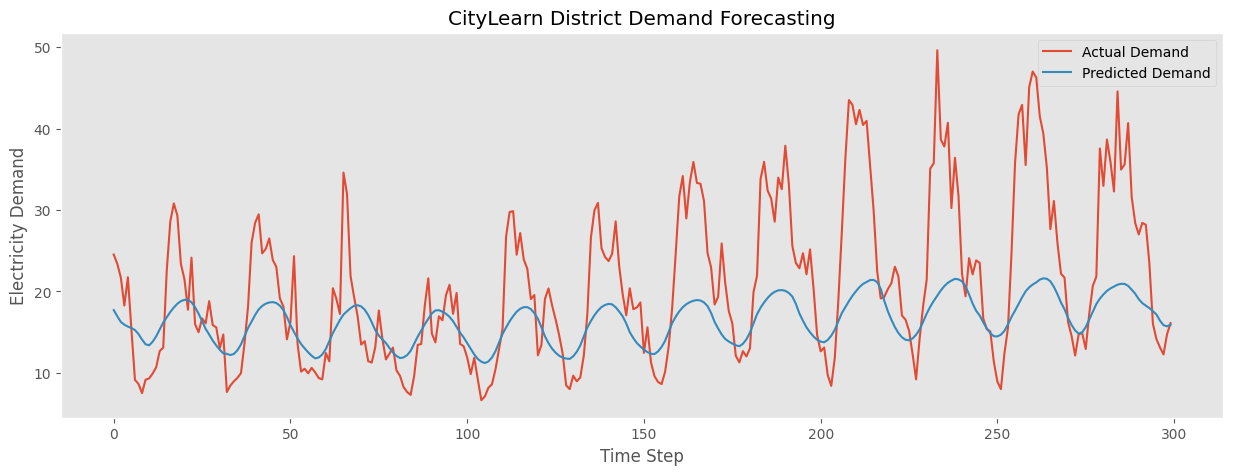

In [43]:
plt.figure(figsize=(15,5))
plt.plot(y_test_unscaled[:300], label='Actual Demand')
plt.plot(y_pred[:300], label='Predicted Demand')
plt.title('CityLearn District Demand Forecasting')
plt.xlabel('Time Step')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid()
plt.show()

## Conclusion
* The CityLearn dataset was processed and transformed into a suitable dataset for electricity demand forecasting.
* Building-level energy consumption data was combined to obtain district-level demand information.
* Weather, electricity pricing, and carbon intensity data were integrated to improve forecasting performance.
* Data cleaning and preprocessing techniques were applied to handle missing values and prepare the dataset.
* Additional features were created to capture important patterns and trends in the data.
* The dataset was normalized and converted into time-series sequences using a lookback window.
* An LSTM (Long Short-Term Memory) neural network was developed and trained for forecasting future demand.
* Model predictions were generated and compared with actual values to assess performance.
* Different evaluation metrics were used to measure forecasting accuracy and model effectiveness.
* The project demonstrated a complete machine learning workflow, including data preparation, feature engineering, model development, training, prediction, and performance evaluation.



